# Sterile-neutrino searches with levitated nanoparticles

This notebook demonstrates the main steps of the sensitivity calculation in
**Carney, Leach & Moore, *"Searches for Massive Neutrinos with Mechanical Quantum
Sensors"*, [PRX Quantum 4, 010315 (2023)](https://doi.org/10.1103/PRXQuantum.4.010315)**
(`refs/sterile_paper.pdf`), implemented in the local `sterile_sens` package.

**Concept.** A radioisotope-doped nanosphere (~100 nm) is optically levitated and its
center-of-mass momentum is monitored continuously near the standard quantum limit (SQL).
When a nucleus inside decays (electron capture or $\beta^-$), the recoil momentum kick of
the sphere — together with the measured secondary particle — reconstructs the momentum of
the emitted neutrino **event by event**:

$$\vec p_\nu = -\left(\Delta\vec p_{\rm sphere} + \vec p_{\rm secondary}\right).$$

A heavy sterile state $\nu_4$ with mass $m_4$ and mixing $|U_{e4}|^2$ shows up as a
displaced population in $|p_\nu|$, since part of the decay energy is spent on its rest mass.

**Pipeline:** sensor noise → decay kinematics → Monte Carlo reconstruction →
profile-likelihood limit → sensitivity curves.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from sterile_sens import (Detector, detector_for, EC_ISOTOPES, BETA_ISOTOPES,
                          simulate_ec, simulate_beta, sensitivity_curve,
                          nll_upper_limit, toy_limit, get_isotope, plotting)
from sterile_sens.constants import p_sql_kev
from sterile_sens.spectra import (beta_spectrum, beta_phase_space_ratio,
                                  ec_phase_space_ratio)

rng = np.random.default_rng(42)
C = plotting.C   # validated categorical palette

## 1. The sensor: momentum resolution at the SQL

For an impulse delivered in a time $\tau \ll \omega_s^{-1}$, a measurement at the SQL
resolves the sphere momentum to (Eq. 5 of the paper)

$$\Delta p_{\rm SQL}=\sqrt{\hbar m_s \omega_s}
 \;=\;15\ {\rm keV}/c\;\Big(\tfrac{m_s}{1\,{\rm fg}}\Big)^{1/2}\Big(\tfrac{\omega_s/2\pi}{100\,{\rm kHz}}\Big)^{1/2}.$$

Per axis the noise is degraded by the information-collection efficiency,
$\sigma_i = \Delta p_{\rm SQL}/\sqrt{\eta_i}$ with $\eta=(0.4,0.4,0.6)$.
All experimental knobs live in the `Detector` dataclass.

 32P default:   100 nm silica   m_s =   1.0472 fg, f0 =   100 kHz -> p_SQL =   15587 eV/c, sigma_axes = [24.64 24.64 20.12] keV/c
 35S default:    50 nm silica   m_s =   0.1309 fg, f0 =    10 kHz -> p_SQL =    1743 eV/c, sigma_axes = [2.76 2.76 2.25] keV/c
  3H default:    25 nm polymer  m_s =   0.0086 fg, f0 =     1 kHz -> p_SQL =     141 eV/c, sigma_axes = [0.22 0.22 0.18] keV/c


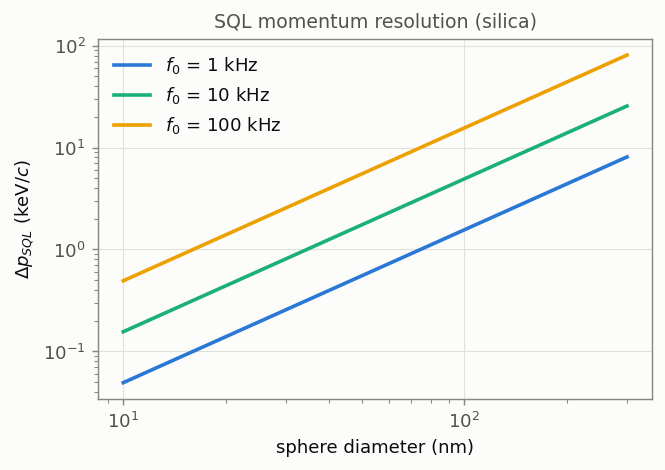

In [2]:
det100 = detector_for("32P")     # 100-nm silica, 100 kHz (paper default)
for name in ["32P", "35S", "3H"]:
    d = detector_for(name)
    print(f"{name:>4s} default: {d.diameter_nm:5.0f} nm {d.material:8s} "
          f"m_s = {d.mass_g*1e15:8.4f} fg, f0 = {d.f_trap_hz/1e3:5.0f} kHz "
          f"-> p_SQL = {d.p_sql*1e3:7.0f} eV/c, sigma_axes = {np.round(d.sigma_p_axes,2)} keV/c")

# scaling with sphere size and trap frequency
diam = np.geomspace(10, 300, 100)
fig, ax = plt.subplots(figsize=(5.5, 3.6))
for f_khz, c in [(1, C[0]), (10, C[1]), (100, C[2])]:
    d = [Detector(diameter_nm=x, f_trap_hz=f_khz*1e3).p_sql for x in diam]
    ax.loglog(diam, d, color=c, label=f"$f_0$ = {f_khz} kHz")
ax.set_xlabel("sphere diameter (nm)"); ax.set_ylabel(r"$\Delta p_{SQL}$ (keV/$c$)")
ax.legend(); ax.set_title("SQL momentum resolution (silica)", color="#52514e");

## 2. Isotopes and count rates

The isotope registries carry the data of Tables I–II (from ENSDF): $Q$ values,
half-lives, and the secondary particles used to *trigger* on a decay
(Auger $e^-$ / x rays for EC, the $\beta$ itself for $\beta^-$ decay).
With ~1% mass loading, a single 100-nm sphere holds $\sim10^5$ unstable atoms.

As a validation, we recompute the paper's "live time to observe $10^4$ events":

In [3]:
paper = {"7Be": 24, "37Ar": 9, "49V": 119, "51Cr": 9, "68Ge": 147, "72Se": 4,
         "3H": 252, "32P": 2.8, "35S": 189, "90Y": 1.7}
print(f"{'isotope':>8s} {'Q (keV)':>9s} {'T1/2 (d)':>9s} {'atoms':>9s} "
      f"{'det./day':>9s} {'live time':>10s} {'paper':>7s}")
for name in paper:
    iso = get_isotope(name); det = detector_for(name)
    sim = (simulate_ec if name in EC_ISOTOPES else simulate_beta)(rng, iso, det, 0.0, 100_000)
    Q = iso.max_E_nu if name in EC_ISOTOPES else iso.Q
    per_day = det.decays(iso.A, iso.halflife_days, 1.0) * sim.rate_factor * sim.efficiency
    print(f"{name:>8s} {Q:9.0f} {iso.halflife_days:9.1f} "
          f"{det.n_isotope_atoms(iso.A):9.2e} {per_day:9.0f} "
          f"{1e4/per_day:7.1f} sd {paper[name]:7.1f}")

 isotope   Q (keV)  T1/2 (d)     atoms  det./day  live time   paper
     7Be       384      53.2  8.99e+05       498    20.1 sd    24.0
    37Ar       814      35.0  1.71e+05      1219     8.2 sd     9.0
     49V       602     330.0  1.29e+05        95   105.6 sd   119.0
    51Cr       752      27.7  1.24e+05      1100     9.1 sd     9.0
    68Ge       107     271.0  9.28e+04        82   121.9 sd   147.0


    72Se       361       8.4  8.77e+04      2733     3.7 sd     4.0
      3H        19    4500.0  3.43e+05        19   524.0 sd   252.0
     32P      1711      14.3  1.97e+05      3805     2.6 sd     2.8
     35S       167      87.4  2.25e+04        70   142.4 sd   189.0
     90Y      2279       2.7  7.01e+04      7193     1.4 sd     1.7


Agreement is within ~20% for all isotopes except ³H (sensitive to unstated
assumptions about the polymer density and trigger for very soft $\beta$s).

## 3. Decay kinematics with a heavy mass state

**Electron capture** is a two-body decay: the neutrino is monoenergetic,
$|p_4| = \sqrt{E_\nu^2 - m_4^2}$ — a heavy state produces a *second, displaced peak*
(Eq. 7). **$\beta^-$ decay** is three-body: the observable is the correlation between the
$\beta$ kinetic energy $T_e$ and $|p_\nu|$, with
$|p_4| = \sqrt{(Q-T_e)^2 - m_4^2}$ (Eq. 9), and the heavy branch is phase-space
suppressed by $r(m_4)=\Gamma(m_4)/\Gamma(0)$.

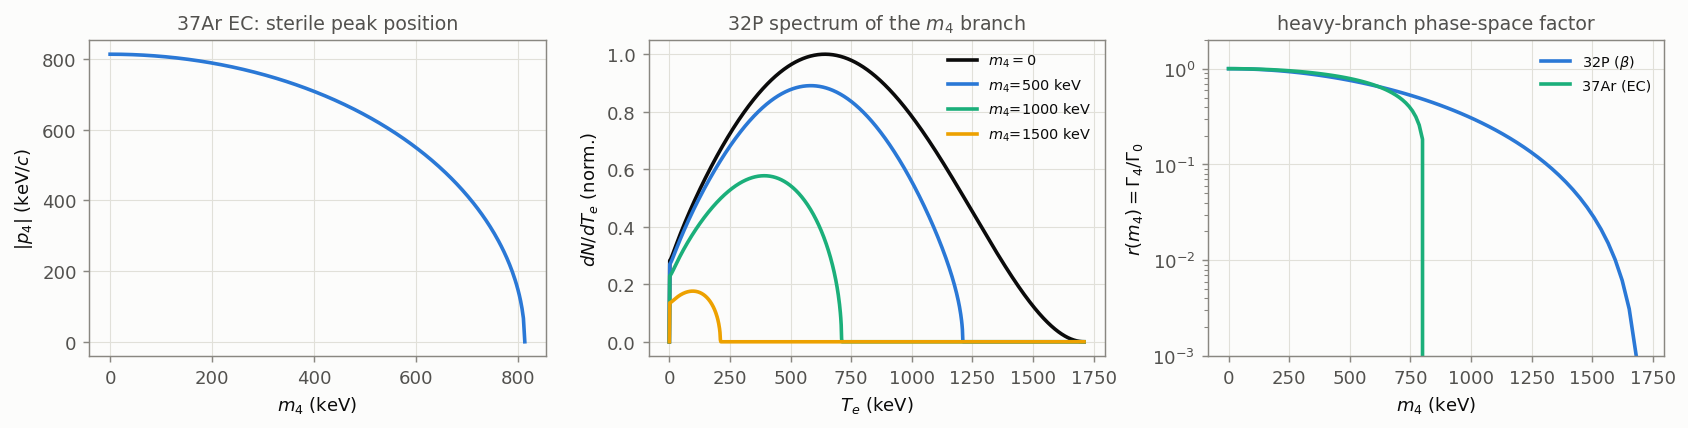

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

# EC: peak position vs m4 (37Ar)
E_nu = EC_ISOTOPES["37Ar"].branches[0].E_nu
m4 = np.linspace(0, E_nu, 300)
axes[0].plot(m4, np.sqrt(E_nu**2 - m4**2), color=C[0])
axes[0].set_xlabel("$m_4$ (keV)"); axes[0].set_ylabel(r"$|p_4|$ (keV/$c$)")
axes[0].set_title("37Ar EC: sterile peak position", color="#52514e")

# beta spectra for 32P with massive neutrino
iso = BETA_ISOTOPES["32P"]
Te = np.linspace(0, iso.Q, 1000)
s0 = beta_spectrum(Te, iso, 0.0)
axes[1].plot(Te, s0/s0.max(), color="#0b0b0b", label="$m_4=0$")
for k, m in enumerate([500, 1000, 1500]):
    s = beta_spectrum(Te, iso, m)
    axes[1].plot(Te, s/s0.max(), color=C[k], label=f"$m_4$={m} keV")
axes[1].set_xlabel("$T_e$ (keV)"); axes[1].set_ylabel("$dN/dT_e$ (norm.)")
axes[1].legend(fontsize=8); axes[1].set_title("32P spectrum of the $m_4$ branch", color="#52514e")

# phase-space suppression
m4g = np.linspace(0, iso.Q, 60)
axes[2].semilogy(m4g, [beta_phase_space_ratio(iso, m) for m in m4g], color=C[0], label=r"32P ($\beta$)")
b37 = EC_ISOTOPES["37Ar"].branches[0]
m4e = np.linspace(0, b37.E_nu, 60)
axes[2].semilogy(m4e, [ec_phase_space_ratio(b37, m) for m in m4e], color=C[1], label="37Ar (EC)")
axes[2].set_xlabel("$m_4$ (keV)"); axes[2].set_ylabel(r"$r(m_4)=\Gamma_4/\Gamma_0$")
axes[2].set_ylim(1e-3, 2); axes[2].legend(fontsize=8)
axes[2].set_title("heavy-branch phase-space factor", color="#52514e")
fig.tight_layout()

## 4. Monte Carlo of decay, transport, and reconstruction

Per simulated decay (`sterile_sens.montecarlo`):

1. draw the decay position uniformly in the sphere and all emission directions isotropically;
2. the **nuclear recoil always stops** in the sphere; **γ/x rays escape freely**;
   **electrons** slow down along a straight path (CSDA range tables for SiO₂/polymer)
   and may stop inside;
3. the sphere kick $\Delta\vec p = -(\vec p_\nu + \vec p_{\rm exit})$ is smeared with the
   per-axis SQL noise;
4. an escaping secondary above threshold triggers the event with 40% probability
   (SiPM solid-angle coverage); its direction is measured to 0.02 rad and, for $\beta$s,
   its energy to $\sigma_E/E = 0.01\sqrt{1\,{\rm MeV}/E}$;
5. the neutrino is reconstructed as $\vec p_\nu = -(\Delta\vec p_{\rm meas} + \vec p_{\rm sec,meas})$.

### Fig. 2: reconstructed spectrum for ³⁷Ar (EC)
30 days with one 100-nm sphere at 1% loading, with a sterile state at
$m_4 = 750$ keV injected at the current limit $|U_{e4}|^2 = 2\times10^{-4}$ —
the tiny displaced peak at $\sqrt{814^2-750^2}\approx317$ keV/$c$ (inset):

saved C:\Users\yuhan\sterile_calc\sterile_sens\..\results\fig2_37Ar_spectrum.png


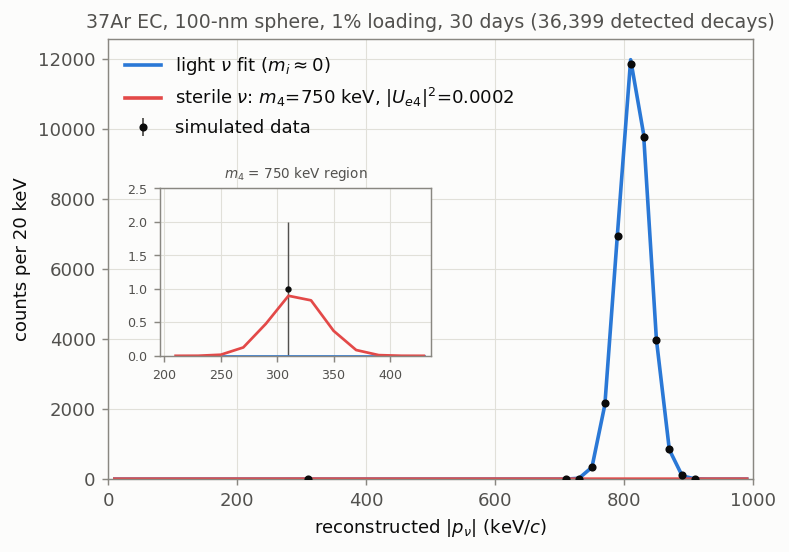

In [5]:
fig = plotting.fig2(iso_name="37Ar", m4=750.0, ue4sq=2e-4, exposure_days=30.0)

### Fig. 3: $|p_\nu|$ vs $T_e$ for ³²P ($\beta^-$)

For $\beta$ decay the discriminating observable is two-dimensional. Heavy-state events
detach from the massless correlation band, most visibly near the endpoint where
$|p_i|-|p_4|\approx m_4$:

saved C:\Users\yuhan\sterile_calc\sterile_sens\..\results\fig3_32P_pnu_vs_Te.png


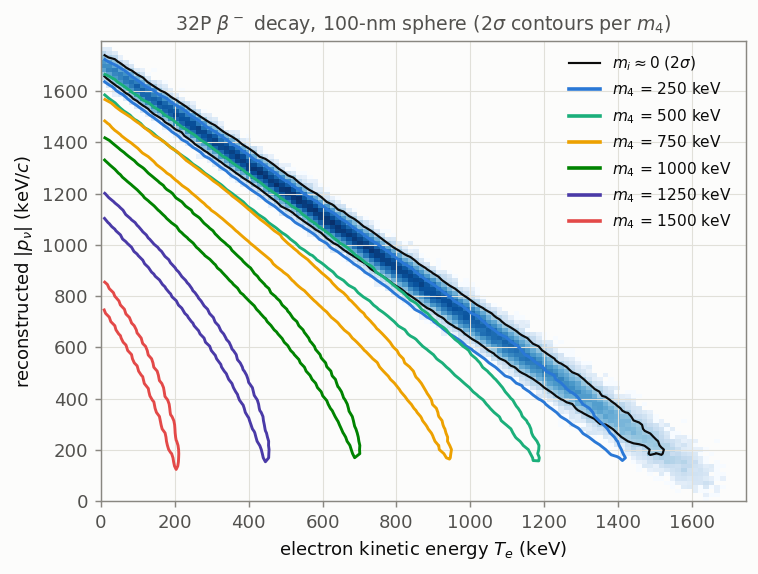

In [6]:
fig = plotting.fig3(iso_name="32P")   # paper's m4 set: 250...1500 keV

## 5. From spectra to a limit: profile-likelihood fit

For each $m_4$ the MC provides normalized PDFs $P_0$ (light $\nu$ only) and $P_4$
(sterile). A binned extended likelihood with expected counts
$\mu_b = \nu P_{0,b} + s P_{4,b}$ is fit to the (Asimov = expectation-valued) data,
profiling the light-state yield $\nu$. The median expected 95% C.L. upper limit solves

$$q(s_{95}) \equiv 2\left[\mathrm{NLL}_{\rm prof}(s_{95}) - \mathrm{NLL}_{\rm min}\right] = 2.706,$$

and converts to the mixing via
$|U_{e4}|^2_{95} = s_{95} \,/\, (N_{\rm decays}\, r(m_4)\, \varepsilon)$.

**Convention note.** The phase-space factor $r(m_4)=\Gamma(m_4)/\Gamma(0)$ in this
conversion is required physics (Shrock 1980), but the paper's Figs. 4–5 evidently omit
it: their sensitivity floors stay flat up to the kinematic endpoint, which with $r$
included would imply a 95% C.L. limit of less than one detected signal event —
impossible. Both conventions are available via `include_phase_space`; the figure
reproductions below default to the paper's convention.

N_decays(30 d) = 1.014e+05,  detected light events = 36306
s95 (Asimov) = 1.35   s95 (median of 200 toys) = 1.35
=> |Ue4|^2 (95% CL) = 9.58e-05 with phase-space factor r=0.39
                    = 3.72e-05 in the paper's convention (no r)
   (existing limit ~2e-4)


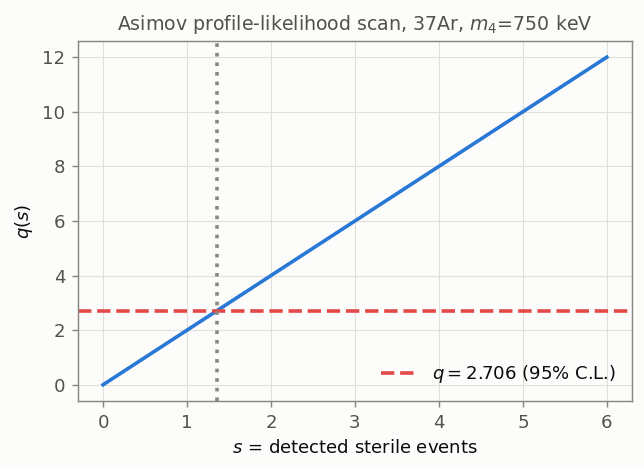

In [7]:
from sterile_sens.sensitivity import _default_bins, _histogram, _simulate, _profiled_nll

iso, det = EC_ISOTOPES["37Ar"], detector_for("37Ar")
bins = _default_bins(iso, det)
light = _simulate(rng, iso, det, 0.0, 200_000)
heavy = _simulate(rng, iso, det, 750.0, 200_000)
p0 = _histogram(light, iso, det, bins); p4 = _histogram(heavy, iso, det, bins)

N_dec  = det.decays(iso.A, iso.halflife_days, 30.0)          # decays in 30 d
N_light = N_dec * light.rate_factor * light.efficiency        # detected (light)
n_asimov = N_light * p0

s_grid = np.linspace(0, 6, 80)
nll0 = _profiled_nll(0.0, n_asimov, p0, p4)
q = np.array([2*(_profiled_nll(s, n_asimov, p0, p4) - nll0) for s in s_grid])

s95 = nll_upper_limit(N_light, p0, p4)
s95_toy = toy_limit(rng, N_light, p0, p4, n_toys=200)
ue4sq_95 = s95 / (N_dec * heavy.rate_factor * heavy.efficiency)      # physical
ue4sq_95_paper = s95 / (N_dec * heavy.branch_factor * heavy.efficiency)

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.plot(s_grid, q, color=C[0])
ax.axhline(2.706, color=C[5], ls="--", label="$q = 2.706$ (95% C.L.)")
ax.axvline(s95, color="#898781", ls=":")
ax.set_xlabel("$s$ = detected sterile events"); ax.set_ylabel("$q(s)$")
ax.legend(); ax.set_title("Asimov profile-likelihood scan, 37Ar, $m_4$=750 keV", color="#52514e")
print(f"N_decays(30 d) = {N_dec:.3e},  detected light events = {N_light:.0f}")
print(f"s95 (Asimov) = {s95:.2f}   s95 (median of 200 toys) = {s95_toy:.2f}")
print(f"=> |Ue4|^2 (95% CL) = {ue4sq_95:.2e} with phase-space factor r={heavy.rate_factor:.2f}")
print(f"                    = {ue4sq_95_paper:.2e} in the paper's convention (no r)")
print( "   (existing limit ~2e-4)")

## 6. Sensitivity projections

`sensitivity_curve` repeats this at every $m_4$; the figure functions default to the
paper's no-$r(m_4)$ convention (noted on the plots) so they can be compared directly
with the paper.

### Fig. 4 — one 100-nm nanosphere for one month

  fig4: 37Ar ...


  fig4: 49V ...


  fig4: 51Cr ...


  fig4: 68Ge ...


  fig4: 72Se ...


  fig4: 32P ...


  fig4: 90Y ...


saved C:\Users\yuhan\sterile_calc\sterile_sens\..\results\fig4_sensitivity.png


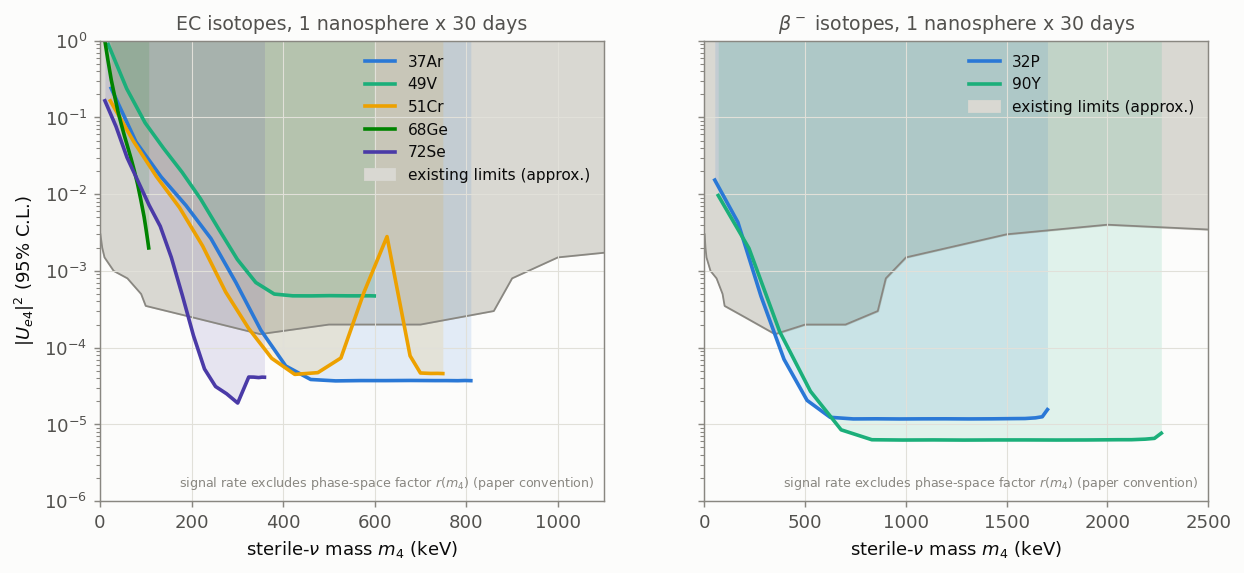

In [8]:
fig = plotting.fig4(n_mc=150_000)   # ~20 s; gray band = schematic existing limits

### Fig. 5 — smaller spheres and larger exposures

³H (25-nm polymer sphere, 1 kHz trap, 20% loading) and ³⁵S (50-nm silica, 10 kHz)
extend the reach to keV-scale masses; arrays and year-long exposures push toward
$|U_{e4}|^2 \sim 10^{-9}$:

  fig5: 32P (100 nm, 100 kHz) ...


  fig5: 35S (50 nm, 10 kHz) ...


  fig5: 3H (25 nm, 1 kHz) ...


saved C:\Users\yuhan\sterile_calc\sterile_sens\..\results\fig5_exposures.png


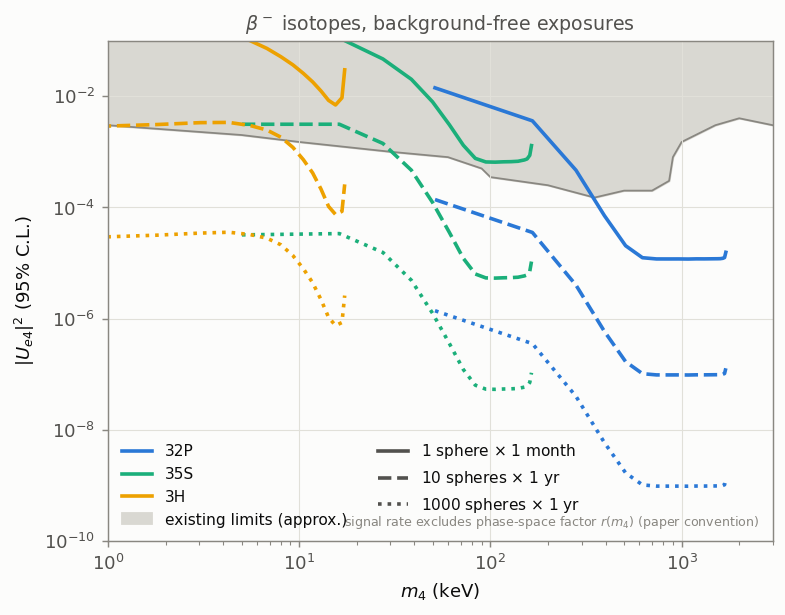

In [9]:
fig = plotting.fig5(n_mc=150_000)

## 7. Customizing the experiment

Everything is a `Detector` field — sphere size/material, loading, trap frequency,
collection efficiencies, resolutions, trigger efficiency, and a `sub_sql_factor` for
squeezed/back-action-evading readout. Example: how the ³²P sensitivity changes with
sphere size and sub-SQL readout at fixed exposure:

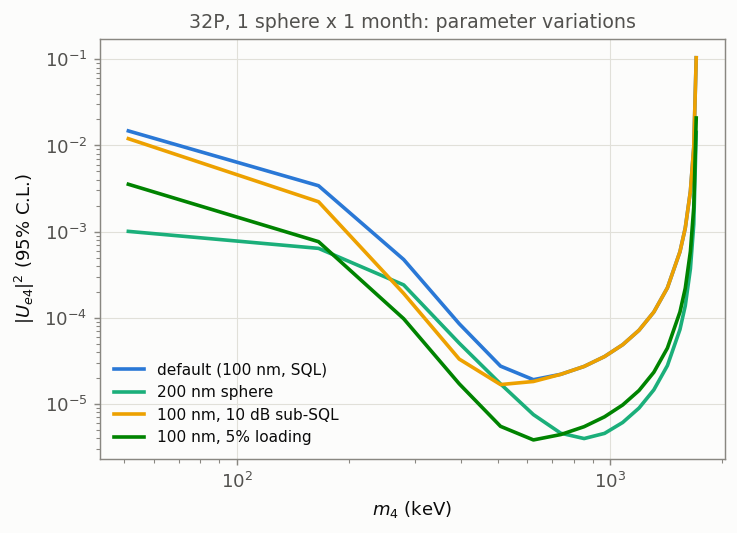

In [10]:
iso = BETA_ISOTOPES["32P"]
variants = {
    "default (100 nm, SQL)":  detector_for("32P"),
    "200 nm sphere":          Detector(diameter_nm=200),
    "100 nm, 10 dB sub-SQL":  Detector(sub_sql_factor=10**(-10/20)),
    "100 nm, 5% loading":     Detector(loading=0.05),
}
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for k, (label, det) in enumerate(variants.items()):
    m4, lim = sensitivity_curve(iso, det, exposure_sphere_days=30.0, n_mc=100_000)
    ok = np.isfinite(lim)
    ax.loglog(m4[ok], lim[ok], color=C[k], label=label)
ax.set_xlabel("$m_4$ (keV)"); ax.set_ylabel("$|U_{e4}|^2$ (95% C.L.)")
ax.set_title("32P, 1 sphere x 1 month: parameter variations", color="#52514e")
ax.legend(fontsize=8.5);

## Notes and caveats

* Figs. 4–5 above use the paper's convention (no heavy-state phase-space suppression in
  the count-to-$|U_{e4}|^2$ conversion); `sensitivity_curve(..., include_phase_space=True)`
  — the API default, used in Sec. 7 — gives the physical limit, weaker by $1/r(m_4)$
  at high mass.
* The statistical treatment uses the **Asimov** (asymptotic) median limit; in the fully
  background-free regime the exact Poisson limit is ~2x weaker ($s_{95}=3.0$ vs $1.35$).
  The toy-MC cross-check above validates the Asimov result for the same test statistic.
* The gray "existing limits" band is a **schematic** envelope
  (`data/existing_limits.csv`) — replace with a proper digitization for quantitative use.
* EC atomic relaxation is reduced to a single secondary per decay; electron stopping uses
  approximate ESTAR/Ashley–Anderson CSDA tables; backgrounds and nuclear-recoil escape
  are neglected (Sec. III D of the paper argues they can be made subdominant).
* See `README.md` for the full model description and package layout.